In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import math

In [ ]:
# For GPU computation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
# Importing Dataset

train_data = datasets.MNIST(root = './data', train = 'train', download = True, transform = transforms.ToTensor())
test_data = datasets.MNIST(root = './data', train = 'test', download = True, transform = transforms.ToTensor())

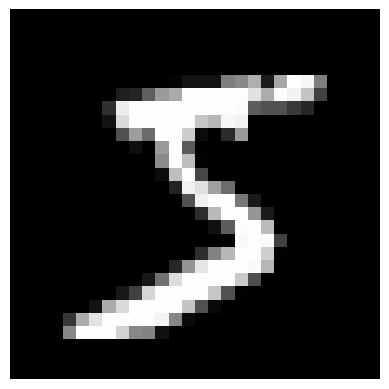

The label for this image is:  5


In [ ]:
# Visualizing the dataset

plt.imshow(train_data[0][0].view(28, 28), cmap = 'gray')
plt.axis('off')
plt.show()
print('The label for this image is: ', train_data[0][1])

In [ ]:
# DataLoader

Batch_Size = 64

train_loader = DataLoader(train_data, batch_size = Batch_Size, shuffle = True)
test_loader = DataLoader(test_data, batch_size = Batch_Size, shuffle = True)

In [ ]:
# Noise schedule

T = 1000                                                      # Number of timestamps

beta = torch.linspace(1e-4, 0.02, T, device = device)         # Amount of noise added in each timestamp
alpha = 1 - beta                                              # The amount of previous image that survived after adding noise(beta)
alpha_bar = torch.cumprod(alpha, dim = 0)                     # Cummalative product of alpha (How much of the original image remains overall)

In [ ]:
print(beta[:5])
print(alpha[:5])
print(alpha_bar[:5])

tensor([1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04],
       device='cuda:0')
tensor([0.9999, 0.9999, 0.9999, 0.9998, 0.9998], device='cuda:0')
tensor([0.9999, 0.9998, 0.9996, 0.9995, 0.9993], device='cuda:0')


In [ ]:
# Forward diffusion

def forward_diff(org_img, timestep):

  noise = torch.randn_like(org_img)

  # Reshape alpha_bar[timestep] to (batch_size, 1, 1, 1) for broadcasting to match the (batch_size, channels, height, width) of org_img and noise
  alpha_bar_timestep_reshaped = alpha_bar[timestep].view(-1, 1, 1, 1)

  # Formula: X_t = sqrt(alpha_bar) * original_img + sqrt(1 - alpha_bar) * noise
  noised_img = torch.sqrt(alpha_bar_timestep_reshaped) * org_img + \
               torch.sqrt(1 - alpha_bar_timestep_reshaped) * noise

  return noised_img, noise

`torch.randn` (not .rand) draws from a standard normal distribution — mean 0, standard deviation 1, written
𝑁
(
0
,
1
). This is not the range [0, 1]. A Gaussian with mean 0 and std 1 can technically produce any real number, though in practice almost all samples fall between about -4 and +4 (that's just how bell curves work — values far from the mean are exponentially rare).

`randn_like(x)` does not sample noise from the image or based on the image's pixel values. The `_like suffix` only copies three things from x:
- its shape (e.g. (batch, 1, 28, 28) for MNIST)
- its dtype (e.g. float32)
- its device (CPU or GPU)

The actual values are pure random Gaussian noise, completely independent of what's inside `x`.

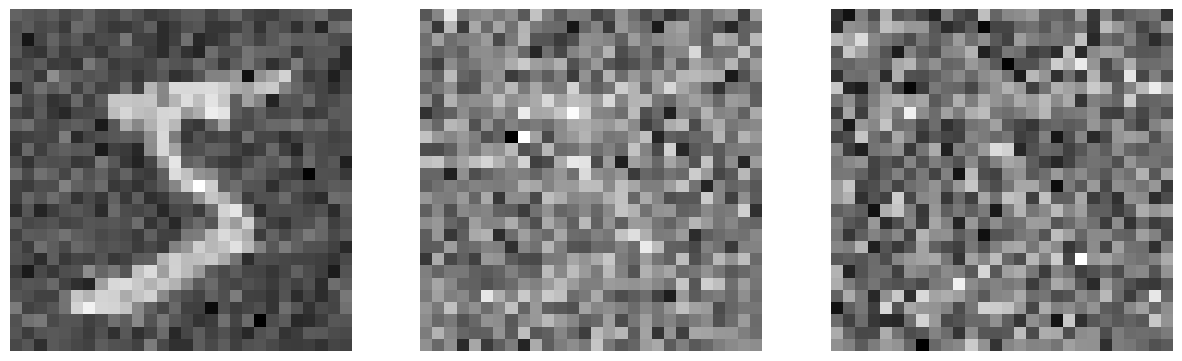

In [ ]:
import torch

# Checking the forward diffusion

tensor = train_data[0][0].to(device)

n_img1, _ = forward_diff(tensor, 50)
n_img2, _ = forward_diff(tensor, 200)
n_img3, _ = forward_diff(tensor, 350)

plt.figure(figsize = (15, 5))

plt.subplot(1, 3, 1)
plt.imshow(n_img1.view(28, 28).cpu(), cmap = 'gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(n_img2.view(28, 28).cpu(), cmap = 'gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(n_img3.view(28, 28).cpu(), cmap = 'gray')
plt.axis('off')

plt.show()

In [ ]:
# Time embedding

class TimeEmbedding(nn.Module):

  def __init__(self, embedding_dim):            # embedding_dim --> number of elements in the time_vector (num(sin values) + num(cos values))
    super().__init__()

    # MLP
    self.linear1 = nn.Linear(embedding_dim, embedding_dim)
    self.silu = nn.SiLU()
    self.linear2 = nn.Linear(embedding_dim, embedding_dim)



  def positional_encoding(self, timestep, embedding_dim):

    timestep = timestep.float().unsqueeze(dim = 1)                 # Changes [B] --> [B, 1]

    emb_index = torch.arange(0, embedding_dim, device = device)    # Creates a tensor: If embedding_dim = 256, then time_vec = [0, 1, 2, ..., 255]
    emb_index = emb_index.unsqueeze(dim = 0)                       # Changes [embedding_dim] --> [1, embedding_dim], i.e: [256] to [1, 256]

    # Positional Encoding
    freqs = 10000 ** (2 * (emb_index // 2) / embedding_dim)
    angles = timestep / freqs

    time_emb = torch.zeros(timestep.shape[0], embedding_dim, device=device)  # Creates a 2D tensor filled with zeros of shape [Batch_Size, embedding_dim]
    time_emb[:, 0::2] = torch.sin(angles[:, 0::2])                           # Even indexes
    time_emb[:, 1::2] = torch.cos(angles[:, 1::2])                           # Odd indexes

    return time_emb


  def forward(self, timestep, embedding_dim):

    time_vec = self.positional_encoding(timestep, embedding_dim)

    time_emd = self.linear1(time_vec)
    time_emd = self.silu(time_emd)
    time_emd = self.linear2(time_emd)

    return time_emd

In [ ]:
class ResBlock(nn.Module):

  def __init__(self, in_ch_len, out_ch_len, t_emb_dim):     # in_ch_len --> input channel length for ResBlock
    super().__init__()                                      # out_ch_len --> channel length of the output feature map from Resblock
                                                            # t_emb_dim --> number of channel in the time embedding vector, which is basically len(Time Embedding Vector)

    self.gn1 = nn.GroupNorm(num_groups = max(1, in_ch_len // 4), num_channels = in_ch_len)  # We take integer division cause num_group expects int values only, and it
                                                                                            # cannot have 0 as its value - So max(1, ...)
    self.silu1 = nn.SiLU()
    self.conv1 = nn.Conv2d(in_ch_len, t_emb_dim, kernel_size = 3, padding = 1)         # Converting feature map's channel to same length as of the time embedding vector,
                                                                                       # so that they can be added later(x + tim_emb)

    self.gn2 = nn.GroupNorm(max(1, (t_emb_dim) // 4), t_emb_dim)
    self.silu2 = nn.SiLU()
    self.conv2 = nn.Conv2d(t_emb_dim, out_ch_len, 3, padding = 1)

  def forward(self, x, time_embedding):

    x = self.gn1(x)
    x = self.silu1(x)
    x = self.conv1(x)

    # Adding Time embedding with Feature map
    time_embedding = time_embedding[:, :, None, None].repeat(1, 1, x.shape[2], x.shape[3]) # Reshaping time_embedding to [batch_size, t_emb_dim, H, W]
                                                                                                       # where H, W match x Corrected to repeat spatial dimensions
    x = x + time_embedding

    x = self.gn2(x)
    x = self.silu2(x)
    x = self.conv2(x)

    return x

The `t_emb_dim` was added to the `GroupNorm` (`gn2`) and `Conv2d` (`conv2`) layers because of how `torch.cat` works and how neural network layers process channels.

Here's the breakdown:

**Channel Concatenation:** Inside the `forward` method, you have the line `x = torch.cat((x, time_embedding), dim = 1)`. This operation joins the `time_embedding` with your main feature map `x` along the channel dimension (`dim=1`).

*   Before concatenation, `x` has `out_ch_len` channels.
*   The `time_embedding` (after being reshaped) has `t_emb_dim` channels.
*   After `torch.cat`, the new `x` will have `out_ch_len + t_emb_dim` channels.

**`nn.GroupNorm` (`gn2`):** The `GroupNorm` layer needs to know the number of input channels it will be normalizing. Since the feature map now has `out_ch_len + t_emb_dim` channels before it passes through `gn2`, we must set `num_channels = out_ch_len + t_emb_dim` in its initialization. This ensures it's correctly configured for the input it receives.

**`nn.Conv2d` (`conv2`):** Similarly, the `Conv2d` layer takes the output of `gn2` as its input. Therefore, its `in_channels` parameter must also reflect this increased channel count: `out_ch_len + t_emb_dim`. If it didn't, the convolution layer wouldn't match the input shape, leading to a `RuntimeError`.

In essence, `t_emb_dim` is passed to `ResBlock.__init__` so that these subsequent layers (`gn2` and `conv2`) can correctly adapt to the modified channel count after the time embedding has been incorporated into the feature map.

In [ ]:
# Self Attention

class Self_Attention(nn.Module):

  def __init__(self, in_ch_len):
    super().__init__()

    self.gn = nn.GroupNorm(max(1, in_ch_len // 4), in_ch_len)
    self.q = nn.Conv2d(in_ch_len, in_ch_len, 1)
    self.k = nn.Conv2d(in_ch_len, in_ch_len, 1)
    self.v = nn.Conv2d(in_ch_len, in_ch_len, 1)

    self.proj = nn.Conv2d(in_ch_len, in_ch_len, 1)

  def forward(self, x):

    B, C, H, W = x.shape

    h = self.gn(x)

    q = self.q(x).reshape(B, C, H*W)                              # Here every pixel is treated as token hence doing H*W
    k = self.k(x).reshape(B, C, H*W)
    v = self.v(x).reshape(B, C, H*W)

    attn = torch.softmax((q.transpose(1,2) @ k) / math.sqrt(C), dim = -1)
    attn = (attn @ v.transpose(1,2)).transpose(1,2)

    attn = attn.reshape(B, C, H, W)                               # Reshaping from [B, C, H*W] --> [B, C, H, W]

    attn = self.proj(attn)

    return x + attn

In [ ]:
# DDPM U-Net

class Unet(nn.Module):

  def __init__(self, t_emb_dim):
    super().__init__()

    # Time embedding vector
    self.t_emd_vec = TimeEmbedding(256)

    # Stem Conv
    self.stem = nn.Conv2d(1, 64, 3, 1, 1)         # It is just to increase the number of channels initially: [64, 1, 28, 28] --> [64, 64, 28, 28]

    # Encoder
    self.en_resblock1 = ResBlock(64, 64, 256)
    self.en_resblock2 = ResBlock(64, 128, 256)
    self.down1 = nn.Conv2d(128, 128, 3, 2, 1)

    self.en_resblock3 = ResBlock(128, 256, 256)
    self.en_resblock4 = ResBlock(256, 256, 256)
    self.down2 = nn.Conv2d(256, 256, 3, 2, 1)

    # Bottleneck
    self.bt_resblock1 = ResBlock(256, 256, 256)
    self.attn = Self_Attention(256)
    self.bt_resblock2 = ResBlock(256, 256, 256)

    # Decoder
    # Corrected up1 to output 14x14 and de_resblock1 input channels to 128 (from up1) + 256 (from skip[1]) = 384
    self.up1 = nn.ConvTranspose2d(256, 128, 3, stride = 2, padding = 1, output_padding = 1)
    self.de_resblock1 = ResBlock(384, 128, 256)
    self.de_resblock2 = ResBlock(128, 128, 256)

    # Corrected up2 to output 28x28 and de_resblock3 input channels to 64 (from up2) + 128 (from skip[0]) = 192
    self.up2 = nn.ConvTranspose2d(128, 64, 3, stride = 2, padding = 1, output_padding = 1)
    self.de_resblock3 = ResBlock(192, 64, 256)
    self.de_resblock4 = ResBlock(64, 64, 256)

    # Final conv layer
    self.final_conv = nn.Conv2d(64, 1, 3, 1, 1)



  # Encoder
  def Encoder(self, x, time_emd):
    skip = []

    x = self.en_resblock1(x, time_emd)
    x = self.en_resblock2(x, time_emd)
    skip.append(x) # skip[0] is 28x28
    x = self.down1(x)

    x = self.en_resblock3(x, time_emd)
    x = self.en_resblock4(x, time_emd)
    skip.append(x) # skip[1] is 14x14
    x = self.down2(x)

    return x, skip

  # Bottleneck
  def Bottleneck(self, x, time_emd):

    x = self.bt_resblock1(x, time_emd)
    x = self.attn(x)
    x = self.bt_resblock2(x, time_emd)

    return x

  # Decoder
  def Decoder(self, x, time_emd, skip):

    # First decoder block: Up from 7x7 to 14x14, concat with skip[1]
    x = self.up1(x) # Output 14x14
    x = torch.cat((x, skip[1]), dim = 1) # Concatenate with skip[1] (14x14)
    x = self.de_resblock1(x, time_emd)
    x = self.de_resblock2(x, time_emd)

    # Second decoder block: Up from 14x14 to 28x28, concat with skip[0]
    x = self.up2(x) # Output 28x28
    x = torch.cat((x, skip[0]), dim = 1) # Concatenate with skip[0] (28x28)
    x = self.de_resblock3(x, time_emd)
    x = self.de_resblock4(x, time_emd)

    return x



  def forward(self, x, timestep):

    # Time Embedding
    time_emd = self.t_emd_vec(timestep, 256)

    # Stem Conv
    x = self.stem(x)

    # Encoder
    x, skip = self.Encoder(x, time_emd)

    # Bottleneck
    x = self.Bottleneck(x, time_emd)

    # Decoder
    x = self.Decoder(x, time_emd, skip)

    # Final Conv
    x = self.final_conv(x)

    return x

In [ ]:
# Initializing the model, and defining Optimizer

model = Unet(256).to(device)

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
# Training

Epochs = 5

for i in range(Epochs):
  total_epoch_loss = 0

  for x, _ in train_loader:

    x = x.to(device)

    # Timestep
    T = 1000                                        # Total diffusion steps
    curr_batch_size = x.shape[0]
    timestep = torch.randint(0, T, (curr_batch_size,), device = device)

    # Forward diffusion
    noised_img, noise = forward_diff(x, timestep)

    # Predict noise
    noise_pred = model(noised_img, timestep)

    # Loss calculation
    loss = nn.functional.mse_loss(noise_pred, noise)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()                  # Accumulate batch loss

  avg_epoch_loss = total_epoch_loss / len(train_loader)

  print(f'Epoch [{i + 1}/{Epochs}]: Loss: {avg_epoch_loss}.4f')

Epoch [1 / 5]: Loss: 0.050850135851095414
Epoch [2 / 5]: Loss: 0.020586846018039277
Epoch [3 / 5]: Loss: 0.01922387726056868
Epoch [4 / 5]: Loss: 0.01825379000565629
Epoch [5 / 5]: Loss: 0.019357201446697656


In [ ]:
# Reverse Diffusion OR Generation

@torch.no_grad()
def sample(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)   # start from pure noise

    for t in reversed(range(T)):
        timestep = torch.full((n_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, timestep)

        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = beta[t]

        z = torch.randn_like(x) if t > 0 else torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise) + torch.sqrt(beta_t) * z

    model.train()
    return x

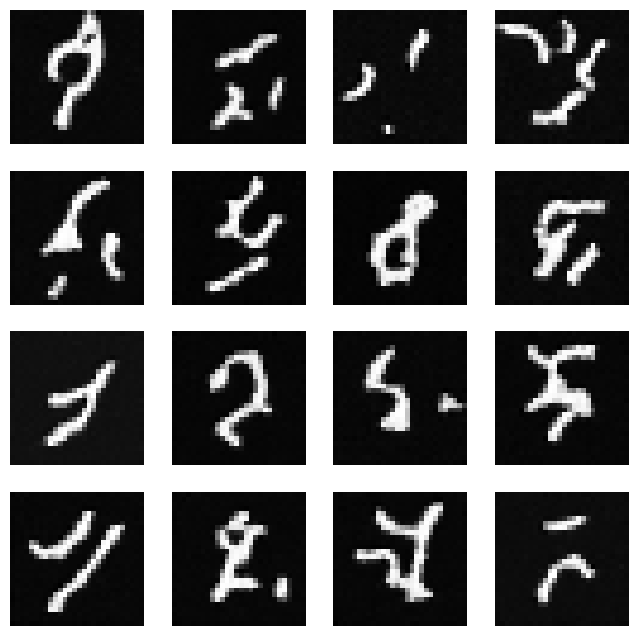

In [ ]:
samples = sample(model, n_samples=16)
samples = samples.cpu().clamp(-1, 1)   # keep in valid range

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()